# Lab Assignment - 4

# Objective: Build a complete machine learning workflow for Airbnb price prediction and make the final model usable through a simple web application.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
os.makedirs("plots", exist_ok=True)
import warnings
warnings.filterwarnings("ignore")

In [2]:
airbnb_df = pd.read_csv("AB_NYC_2019.csv")
airbnb_df

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,36484665,Charming one bedroom - newly renovated rowhouse,8232441,Sabrina,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,NaN,NaN,2,9
48891,36485057,Affordable room in Bushwick/East Williamsburg,6570630,Marisol,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,NaN,NaN,2,36
48892,36485431,Sunny Studio at Historical Neighborhood,23492952,Ilgar & Aysel,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,NaN,NaN,1,27
48893,36485609,43rd St. Time Square-cozy single bed,30985759,Taz,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,NaN,NaN,6,2


In [3]:
print("Shape:", airbnb_df.shape)

Shape: (48895, 16)


In [4]:
airbnb_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

In [5]:
airbnb_df.isnull().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [6]:
missing_percent = (airbnb_df.isnull().sum() / len(airbnb_df)) * 100
missing_percent[missing_percent > 0].sort_values(ascending=False)

reviews_per_month    20.558339
last_review          20.558339
host_name             0.042949
name                  0.032723
dtype: float64

In [7]:
airbnb_df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [8]:
categorical_columns = airbnb_df.select_dtypes(include="object").columns
for column in categorical_columns:
    print(f"{column}: {airbnb_df[column].nunique()} unique values")

name: 47905 unique values
host_name: 11452 unique values
neighbourhood_group: 5 unique values
neighbourhood: 221 unique values
room_type: 3 unique values
last_review: 1764 unique values


In [9]:
print("Minimum price:", airbnb_df["price"].min())
print("Maximum price:", airbnb_df["price"].max())
print("Mean price:", airbnb_df["price"].mean())
print("Median price:", airbnb_df["price"].median())
print("Zero-price listings:", (airbnb_df["price"] == 0).sum())

Minimum price: 0
Maximum price: 10000
Mean price: 152.7206871868289
Median price: 106.0
Zero-price listings: 11


In [10]:
airbnb_df[airbnb_df["price"] == 0]

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
23161,18750597,"Huge Brooklyn Brownstone Living, Close to it all.",8993084,Kimberly,Brooklyn,Bedford-Stuyvesant,40.69023,-73.95428,Private room,0,4,1,2018-01-06,0.05,4,28
25433,20333471,★Hostel Style Room | Ideal Traveling Buddies★,131697576,Anisha,Bronx,East Morrisania,40.83296,-73.88668,Private room,0,2,55,2019-06-24,2.56,4,127
25634,20523843,"MARTIAL LOFT 3: REDEMPTION (upstairs, 2nd room)",15787004,Martial Loft,Brooklyn,Bushwick,40.69467,-73.92433,Private room,0,2,16,2019-05-18,0.71,5,0
25753,20608117,"Sunny, Quiet Room in Greenpoint",1641537,Lauren,Brooklyn,Greenpoint,40.72462,-73.94072,Private room,0,2,12,2017-10-27,0.53,2,0
25778,20624541,Modern apartment in the heart of Williamsburg,10132166,Aymeric,Brooklyn,Williamsburg,40.70838,-73.94645,Entire home/apt,0,5,3,2018-01-02,0.15,1,73
25794,20639628,Spacious comfortable master bedroom with nice ...,86327101,Adeyemi,Brooklyn,Bedford-Stuyvesant,40.68173,-73.91342,Private room,0,1,93,2019-06-15,4.28,6,176
25795,20639792,Contemporary bedroom in brownstone with nice view,86327101,Adeyemi,Brooklyn,Bedford-Stuyvesant,40.68279,-73.91170,Private room,0,1,95,2019-06-21,4.37,6,232
25796,20639914,Cozy yet spacious private brownstone bedroom,86327101,Adeyemi,Brooklyn,Bedford-Stuyvesant,40.68258,-73.91284,Private room,0,1,95,2019-06-23,4.35,6,222
26259,20933849,the best you can find,13709292,Qiuchi,Manhattan,Murray Hill,40.75091,-73.97597,Entire home/apt,0,3,0,NaN,NaN,1,0
26841,21291569,Coliving in Brooklyn! Modern design / Shared room,101970559,Sergii,Brooklyn,Bushwick,40.69211,-73.90670,Shared room,0,30,2,2019-06-22,0.11,6,333


In [11]:
airbnb_df = airbnb_df[airbnb_df["price"] > 0].copy()
print("Dataset shape after removing zero-price listings:", airbnb_df.shape)
print("Remaining zero-price listings:", (airbnb_df["price"] == 0).sum())

Dataset shape after removing zero-price listings: (48884, 16)
Remaining zero-price listings: 0


In [12]:
missing_values = airbnb_df.isnull().sum()
print(missing_values[missing_values > 0])

name                    16
host_name               21
last_review          10051
reviews_per_month    10051
dtype: int64


In [13]:
airbnb_df = airbnb_df.drop(columns=["name", "host_name", "last_review"])
print("Dataset shape:", airbnb_df.shape)
print("\nRemaining missing values:")
print(airbnb_df.isnull().sum()[airbnb_df.isnull().sum() > 0])

Dataset shape: (48884, 13)

Remaining missing values:
reviews_per_month    10051
dtype: int64


In [14]:
airbnb_df["reviews_per_month"] = airbnb_df["reviews_per_month"].fillna(0)
print("Missing reviews_per_month:", airbnb_df["reviews_per_month"].isnull().sum())

Missing reviews_per_month: 0


In [15]:
print("Duplicate rows:", airbnb_df.duplicated().sum())

Duplicate rows: 0


In [16]:
print("Neighbourhood Groups:")
print(airbnb_df["neighbourhood_group"].value_counts())
print("\nRoom Types:")
print(airbnb_df["room_type"].value_counts())

Neighbourhood Groups:
neighbourhood_group
Manhattan        21660
Brooklyn         20095
Queens            5666
Bronx             1090
Staten Island      373
Name: count, dtype: int64

Room Types:
room_type
Entire home/apt    25407
Private room       22319
Shared room         1158
Name: count, dtype: int64


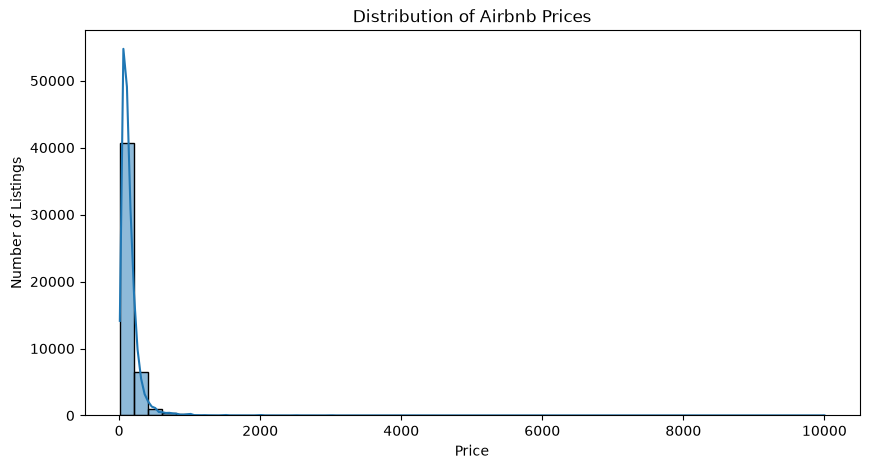

In [17]:
plt.figure(figsize=(10, 5))
sns.histplot(airbnb_df["price"], bins=50, kde=True)
plt.title("Distribution of Airbnb Prices")
plt.xlabel("Price")
plt.ylabel("Number of Listings")
plt.show()

In [18]:
print(airbnb_df["price"].quantile([0.50, 0.75, 0.90, 0.95, 0.99, 0.995, 1.00]))

0.500      106.0
0.750      175.0
0.900      269.0
0.950      355.0
0.990      799.0
0.995     1000.0
1.000    10000.0
Name: price, dtype: float64


In [19]:
Q1 = airbnb_df["price"].quantile(0.25)
Q3 = airbnb_df["price"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = airbnb_df[
    (airbnb_df["price"] < lower_bound) |
    (airbnb_df["price"] > upper_bound)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)
print("Number of outliers:", len(outliers))

Q1: 69.0
Q3: 175.0
IQR: 106.0
Lower bound: -90.0
Upper bound: 334.0
Number of outliers: 2972


In [20]:
price_thresholds = [334, 799, 1000, 2000, 5000]
for threshold in price_thresholds:
    count = (airbnb_df["price"] > threshold).sum()
    print(f"Listings with price > ${threshold}: {count}")

Listings with price > $334: 2972
Listings with price > $799: 474
Listings with price > $1000: 239
Listings with price > $2000: 86
Listings with price > $5000: 20


In [21]:
extreme_prices = airbnb_df[airbnb_df["price"] > 1000]

print("Number of listings above $1,000:", len(extreme_prices))

print("\nRoom type:")
print(extreme_prices["room_type"].value_counts())

print("\nNeighbourhood group:")
print(extreme_prices["neighbourhood_group"].value_counts())

print("\nPrice summary:")
print(extreme_prices["price"].describe())

Number of listings above $1,000: 239

Room type:
room_type
Entire home/apt    191
Private room        46
Shared room          2
Name: count, dtype: int64

Neighbourhood group:
neighbourhood_group
Manhattan        172
Brooklyn          54
Queens            10
Staten Island      2
Bronx              1
Name: count, dtype: int64

Price summary:
count      239.000000
mean      2481.866109
std       1894.193824
min       1002.000000
25%       1311.500000
50%       1799.000000
75%       2775.000000
max      10000.000000
Name: price, dtype: float64


In [22]:
extreme_listings = airbnb_df[airbnb_df["price"] > 5000]

print(extreme_listings[
    [
        "id",
        "neighbourhood_group",
        "neighbourhood",
        "room_type",
        "price",
        "minimum_nights",
        "number_of_reviews",
        "availability_365"
    ]
].sort_values("price", ascending=False))

             id neighbourhood_group      neighbourhood        room_type  \
17692  13894339            Brooklyn         Greenpoint  Entire home/apt   
29238  22436899           Manhattan    Upper West Side  Entire home/apt   
9151    7003697              Queens            Astoria     Private room   
6530    4737930           Manhattan        East Harlem  Entire home/apt   
12342   9528920           Manhattan    Lower East Side     Private room   
40433  31340283           Manhattan    Lower East Side  Entire home/apt   
30268  23377410           Manhattan            Tribeca  Entire home/apt   
4377    2953058            Brooklyn       Clinton Hill  Entire home/apt   
29662  22779726           Manhattan    Upper East Side  Entire home/apt   
42523  33007610           Manhattan  Battery Park City  Entire home/apt   
45666  34895693            Brooklyn      East Flatbush     Private room   
44034  33998396           Manhattan            Chelsea  Entire home/apt   
48043  36056808          

In [23]:
airbnb_df["price"] = airbnb_df["price"].clip(upper=1000)
print("Maximum price after capping:", airbnb_df["price"].max())
print("Listings at $1,000:", (airbnb_df["price"] == 1000).sum())

Maximum price after capping: 1000
Listings at $1,000: 298


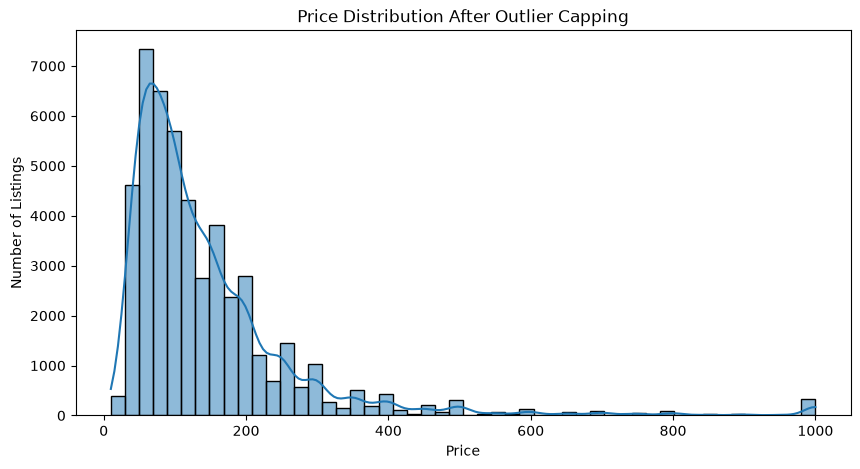

In [24]:
plt.figure(figsize=(10, 5))
sns.histplot(airbnb_df["price"], bins=50, kde=True)
plt.title("Price Distribution After Outlier Capping")
plt.xlabel("Price")
plt.ylabel("Number of Listings")
plt.show()

In [25]:
numeric_columns = airbnb_df.select_dtypes(include=np.number).columns

print(airbnb_df[numeric_columns].describe().T)

                                  count          mean           std  \
id                              48884.0  1.901679e+07  1.098432e+07   
host_id                         48884.0  6.762203e+07  7.861666e+07   
latitude                        48884.0  4.072895e+01  5.453177e-02   
longitude                       48884.0 -7.395218e+01  4.615874e-02   
price                           48884.0  1.455100e+02  1.309466e+02   
minimum_nights                  48884.0  7.029887e+00  2.051222e+01   
number_of_reviews               48884.0  2.327199e+01  4.455133e+01   
reviews_per_month               48884.0  1.090800e+00  1.597213e+00   
calculated_host_listings_count  48884.0  7.144628e+00  3.295619e+01   
availability_365                48884.0  1.127795e+02  1.316273e+02   

                                       min           25%           50%  \
id                              2539.00000  9.470548e+06  1.967574e+07   
host_id                         2438.00000  7.817310e+06  3.079257e+07

In [26]:
print("Minimum nights > 30:", (airbnb_df["minimum_nights"] > 30).sum())
print("Minimum nights > 90:", (airbnb_df["minimum_nights"] > 90).sum())
print("Minimum nights > 180:", (airbnb_df["minimum_nights"] > 180).sum())
print("Minimum nights > 365:", (airbnb_df["minimum_nights"] > 365).sum())

print("\nTop 10 minimum_nights values:")
print(airbnb_df["minimum_nights"].sort_values(ascending=False).head(10).to_list())

Minimum nights > 30: 747
Minimum nights > 90: 197
Minimum nights > 180: 81
Minimum nights > 365: 14

Top 10 minimum_nights values:
[1250, 1000, 999, 999, 999, 500, 500, 500, 500, 500]


In [27]:
print(
    airbnb_df.groupby(
        pd.cut(
            airbnb_df["minimum_nights"],
            bins=[0, 3, 7, 30, 90, 180, 365, 1250]
        )
    )["price"].agg(["count", "mean", "median"])
)

                count        mean  median
minimum_nights                           
(0, 3]          32408  142.385121   100.0
(3, 7]           9145  151.430071   120.0
(7, 30]          6584  149.776276   120.0
(30, 90]          550  163.249091   120.0
(90, 180]         116  202.982759   100.0
(180, 365]         67  186.283582   130.0
(365, 1250]        14  137.571429   112.5


In [28]:
extreme_nights = airbnb_df[airbnb_df["minimum_nights"] > 365]

print(extreme_nights[
    ["neighbourhood_group", "neighbourhood", "room_type",
     "price", "minimum_nights", "number_of_reviews",
     "availability_365"]
].sort_values("minimum_nights", ascending=False).to_string(index=False))

neighbourhood_group      neighbourhood       room_type  price  minimum_nights  number_of_reviews  availability_365
          Manhattan  Greenwich Village Entire home/apt    180            1250                  2               365
          Manhattan  Battery Park City Entire home/apt    400            1000                  0               362
           Brooklyn       Williamsburg    Private room     79             999                 24               249
          Manhattan  Greenwich Village     Shared room    110             999                  0               365
          Manhattan             Harlem Entire home/apt     99             999                  2                42
          Manhattan             Harlem Entire home/apt     75             500                  0               362
           Brooklyn       Williamsburg Entire home/apt    140             500                  0               331
           Brooklyn         Kensington    Private room     45             500   

In [29]:
airbnb_df["minimum_nights"] = airbnb_df["minimum_nights"].clip(upper=365)

print("Maximum minimum_nights after capping:", airbnb_df["minimum_nights"].max())
print("Listings at 365:", (airbnb_df["minimum_nights"] == 365).sum())

Maximum minimum_nights after capping: 365
Listings at 365: 43


In [30]:
print("Number of reviews > 100:", (airbnb_df["number_of_reviews"] > 100).sum())
print("Number of reviews > 200:", (airbnb_df["number_of_reviews"] > 200).sum())
print("Number of reviews > 400:", (airbnb_df["number_of_reviews"] > 400).sum())

print("\nTop 10 number_of_reviews values:")
print(airbnb_df["number_of_reviews"].sort_values(ascending=False).head(10).to_list())

Number of reviews > 100: 2995
Number of reviews > 200: 635
Number of reviews > 400: 39

Top 10 number_of_reviews values:
[629, 607, 597, 594, 576, 543, 540, 510, 488, 480]


In [31]:
print("Reviews per month > 5:", (airbnb_df["reviews_per_month"] > 5).sum())
print("Reviews per month > 10:", (airbnb_df["reviews_per_month"] > 10).sum())
print("Reviews per month > 20:", (airbnb_df["reviews_per_month"] > 20).sum())
print("Reviews per month > 40:", (airbnb_df["reviews_per_month"] > 40).sum())

print("\nTop 10 reviews_per_month values:")
print(airbnb_df["reviews_per_month"].sort_values(ascending=False).head(10).to_list())

Reviews per month > 5: 1467
Reviews per month > 10: 81
Reviews per month > 20: 3
Reviews per month > 40: 1

Top 10 reviews_per_month values:
[58.5, 27.95, 20.94, 19.75, 17.82, 16.81, 16.22, 16.03, 15.78, 15.32]


In [32]:
print("Host listings > 10:", (airbnb_df["calculated_host_listings_count"] > 10).sum())
print("Host listings > 50:", (airbnb_df["calculated_host_listings_count"] > 50).sum())
print("Host listings > 100:", (airbnb_df["calculated_host_listings_count"] > 100).sum())
print("Host listings > 200:", (airbnb_df["calculated_host_listings_count"] > 200).sum())

print("\nTop 10 calculated_host_listings_count values:")
print(airbnb_df["calculated_host_listings_count"].sort_values(ascending=False).head(10).to_list())

Host listings > 10: 2967
Host listings > 50: 1322
Host listings > 100: 783
Host listings > 200: 559

Top 10 calculated_host_listings_count values:
[327, 327, 327, 327, 327, 327, 327, 327, 327, 327]


In [33]:
print("Availability = 0:", (airbnb_df["availability_365"] == 0).sum())
print("Availability = 365:", (airbnb_df["availability_365"] == 365).sum())

print("\nUnique availability values:", airbnb_df["availability_365"].nunique())

print("\nTop 10 availability_365 values:")
print(airbnb_df["availability_365"].value_counts().head(10))

Availability = 0: 17530
Availability = 365: 1295

Unique availability values: 366

Top 10 availability_365 values:
availability_365
0      17530
365     1295
364      491
1        408
89       361
5        340
3        306
179      301
90       290
2        270
Name: count, dtype: int64


In [34]:
correlation = airbnb_df.corr(numeric_only=True)
print(correlation["price"].sort_values(ascending=False))

price                             1.000000
availability_365                  0.121133
calculated_host_listings_count    0.112630
latitude                          0.057670
minimum_nights                    0.040430
host_id                           0.029395
id                                0.018996
number_of_reviews                -0.063526
reviews_per_month                -0.064973
longitude                        -0.247066
Name: price, dtype: float64


In [35]:
# Check the columns before feature selection
print("Columns in dataset:")
print(airbnb_df.columns.tolist())

Columns in dataset:
['id', 'host_id', 'neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']


In [36]:
airbnb_df = airbnb_df.drop(columns=["id", "host_id"])

print("Columns after removing identifiers:")
print(airbnb_df.columns.tolist())

Columns after removing identifiers:
['neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']


In [37]:
print("Dataset shape:", airbnb_df.shape)
print("\nMissing values:")
print(airbnb_df.isnull().sum())
print("\nData types:")
print(airbnb_df.dtypes)

Dataset shape: (48884, 11)

Missing values:
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
dtype: int64

Data types:
neighbourhood_group                   str
neighbourhood                         str
latitude                          float64
longitude                         float64
room_type                             str
price                               int64
minimum_nights                      int64
number_of_reviews                   int64
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
dtype: object


In [38]:
print("Price Statistics:")
print(airbnb_df["price"].describe())

print("\nPrice Quantiles:")
print(airbnb_df["price"].quantile([0.50, 0.75, 0.90, 0.95, 0.99]))

print("\nPrice Skewness:", airbnb_df["price"].skew())

Price Statistics:
count    48884.000000
mean       145.510024
std        130.946570
min         10.000000
25%         69.000000
50%        106.000000
75%        175.000000
max       1000.000000
Name: price, dtype: float64

Price Quantiles:
0.50    106.0
0.75    175.0
0.90    269.0
0.95    355.0
0.99    799.0
Name: price, dtype: float64

Price Skewness: 3.3575984923095668


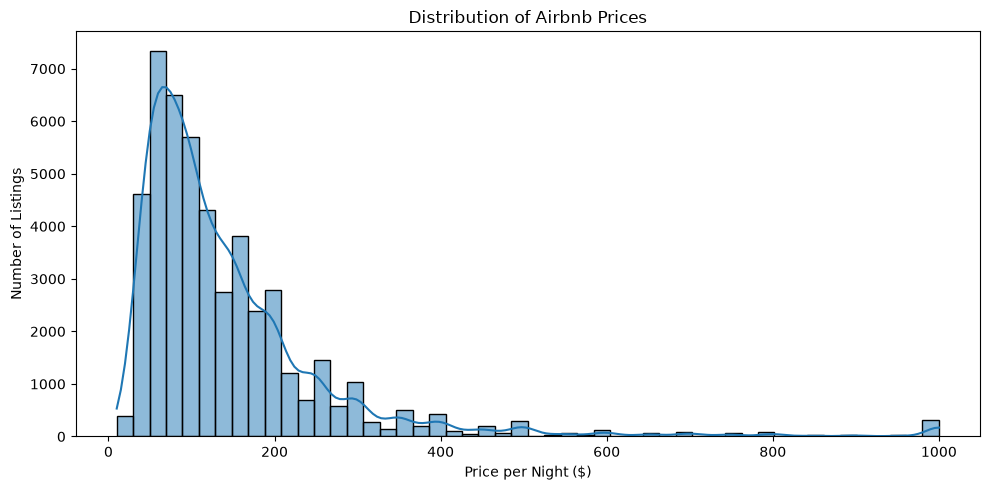

In [39]:
plt.figure(figsize=(10, 5))

sns.histplot(airbnb_df["price"], bins=50, kde=True)

plt.title("Distribution of Airbnb Prices")
plt.xlabel("Price per Night ($)")
plt.ylabel("Number of Listings")
plt.tight_layout()

plt.savefig("plots/price_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [40]:
numeric_features = [
    "latitude",
    "longitude",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365",
    "price"
]
correlation = airbnb_df[numeric_features].corr()["price"].sort_values(ascending=False)
print(correlation)

price                             1.000000
availability_365                  0.121133
calculated_host_listings_count    0.112630
latitude                          0.057670
minimum_nights                    0.040430
number_of_reviews                -0.063526
reviews_per_month                -0.064973
longitude                        -0.247066
Name: price, dtype: float64


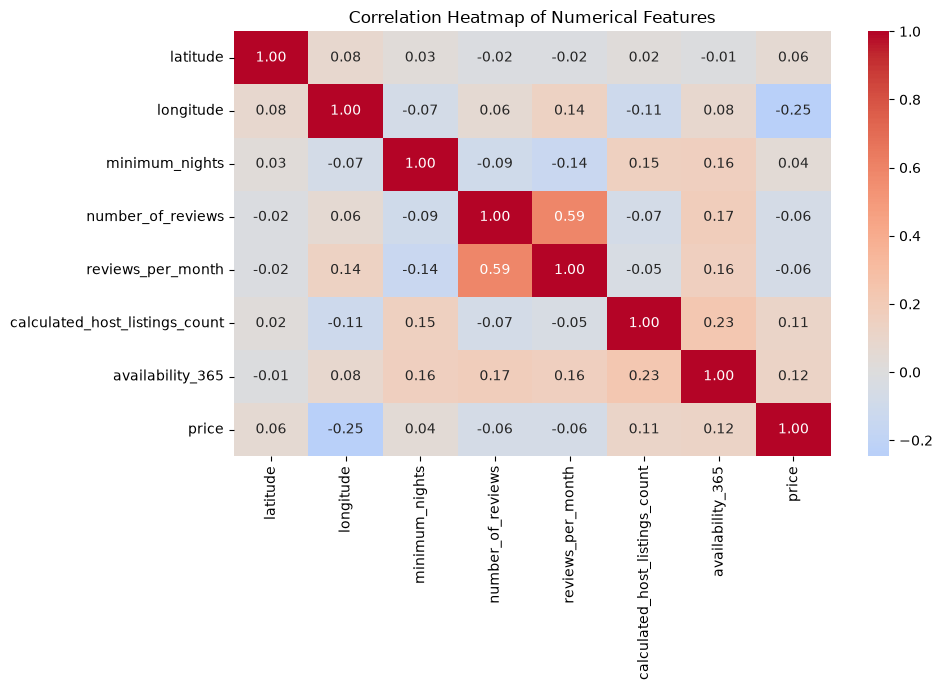

In [41]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    airbnb_df[numeric_features].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()

plt.savefig("plots/correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

In [42]:
room_counts = airbnb_df["room_type"].value_counts()
print(room_counts)

room_type
Entire home/apt    25407
Private room       22319
Shared room         1158
Name: count, dtype: int64


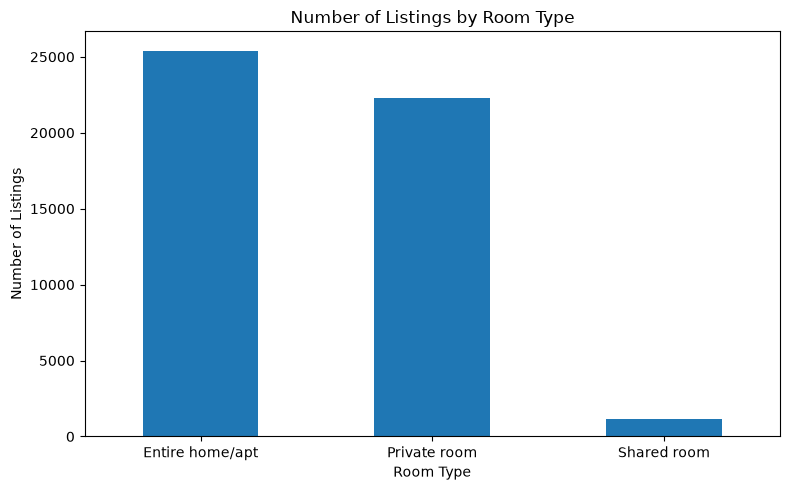

In [43]:
plt.figure(figsize=(8, 5))

room_counts.plot(kind="bar")

plt.title("Number of Listings by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Number of Listings")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig("plots/listings_by_room_type.png", dpi=300, bbox_inches="tight")
plt.show()

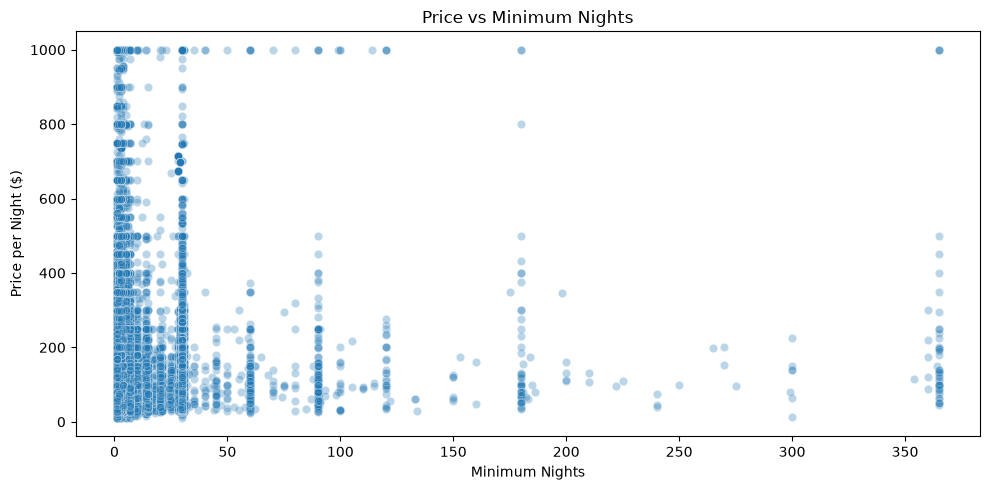

In [44]:
plt.figure(figsize=(10, 5))

sns.scatterplot(
    data=airbnb_df,
    x="minimum_nights",
    y="price",
    alpha=0.3
)

plt.title("Price vs Minimum Nights")
plt.xlabel("Minimum Nights")
plt.ylabel("Price per Night ($)")
plt.tight_layout()

plt.savefig("plots/price_vs_minimum_nights.png", dpi=300, bbox_inches="tight")
plt.show()

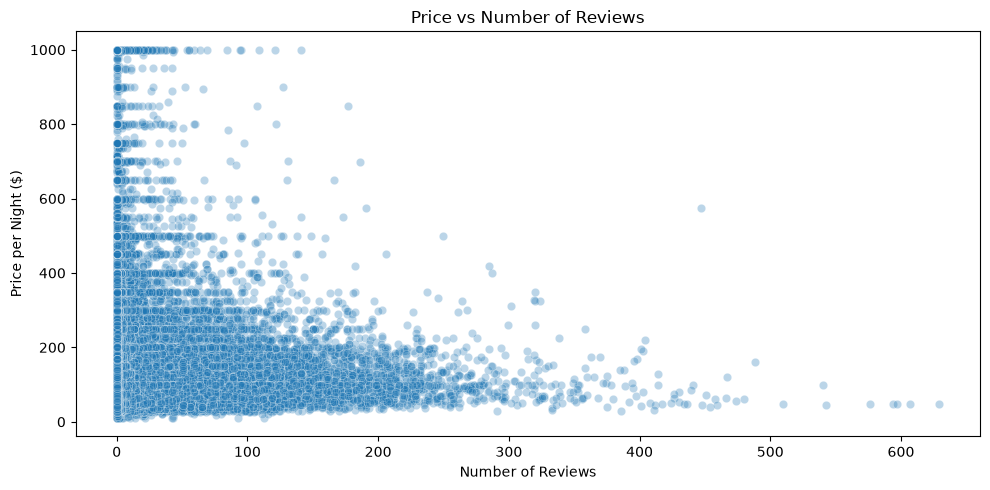

In [45]:
plt.figure(figsize=(10, 5))

sns.scatterplot(
    data=airbnb_df,
    x="number_of_reviews",
    y="price",
    alpha=0.3
)

plt.title("Price vs Number of Reviews")
plt.xlabel("Number of Reviews")
plt.ylabel("Price per Night ($)")
plt.tight_layout()

plt.savefig("plots/price_vs_number_of_reviews.png", dpi=300, bbox_inches="tight")
plt.show()

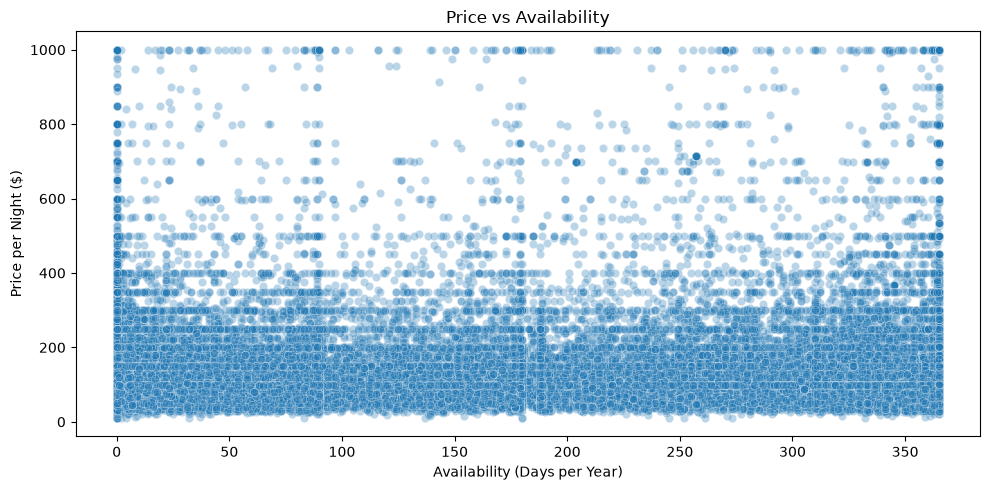

In [46]:
plt.figure(figsize=(10, 5))

sns.scatterplot(
    data=airbnb_df,
    x="availability_365",
    y="price",
    alpha=0.3
)

plt.title("Price vs Availability")
plt.xlabel("Availability (Days per Year)")
plt.ylabel("Price per Night ($)")
plt.tight_layout()

plt.savefig("plots/price_vs_availability.png", dpi=300, bbox_inches="tight")
plt.show()

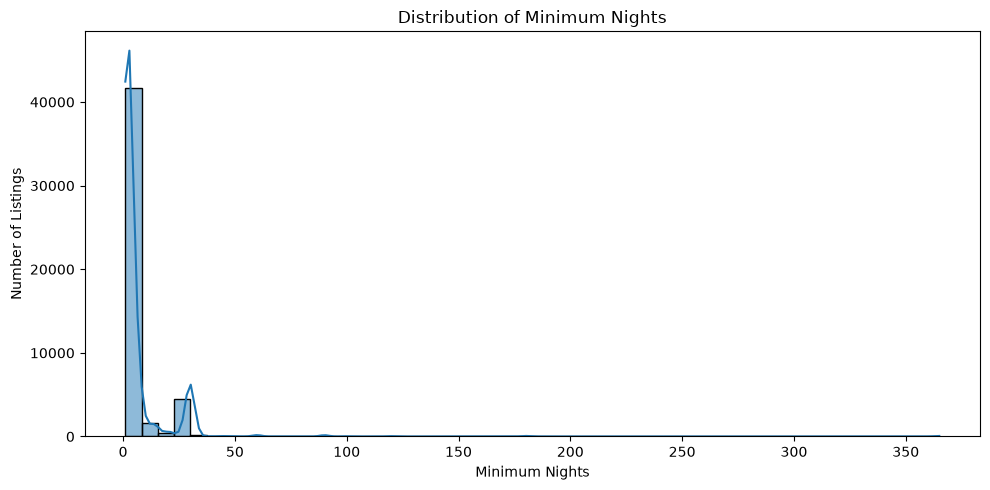

In [47]:
plt.figure(figsize=(10, 5))

sns.histplot(
    airbnb_df["minimum_nights"],
    bins=50,
    kde=True
)

plt.title("Distribution of Minimum Nights")
plt.xlabel("Minimum Nights")
plt.ylabel("Number of Listings")
plt.tight_layout()

plt.savefig("plots/minimum_nights_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

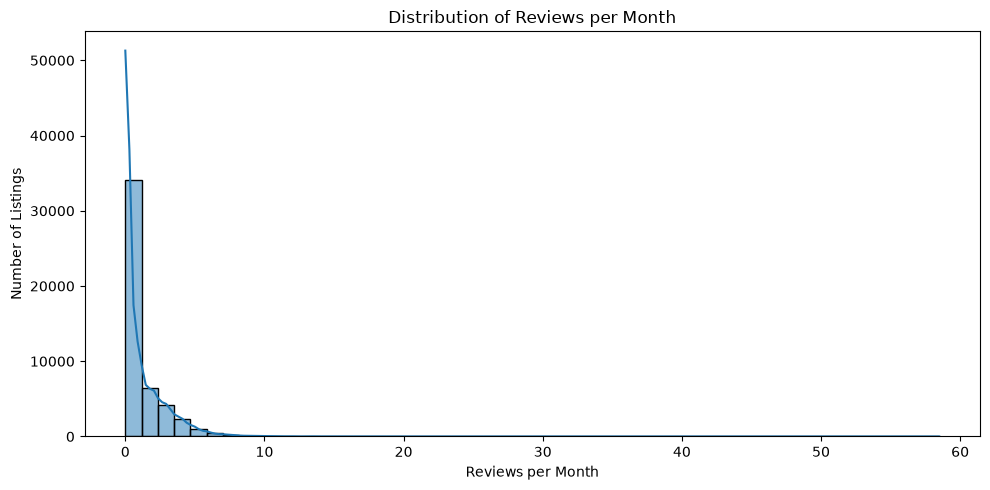

In [48]:
plt.figure(figsize=(10, 5))

sns.histplot(
    airbnb_df["reviews_per_month"],
    bins=50,
    kde=True
)

plt.title("Distribution of Reviews per Month")
plt.xlabel("Reviews per Month")
plt.ylabel("Number of Listings")
plt.tight_layout()

plt.savefig("plots/reviews_per_month_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

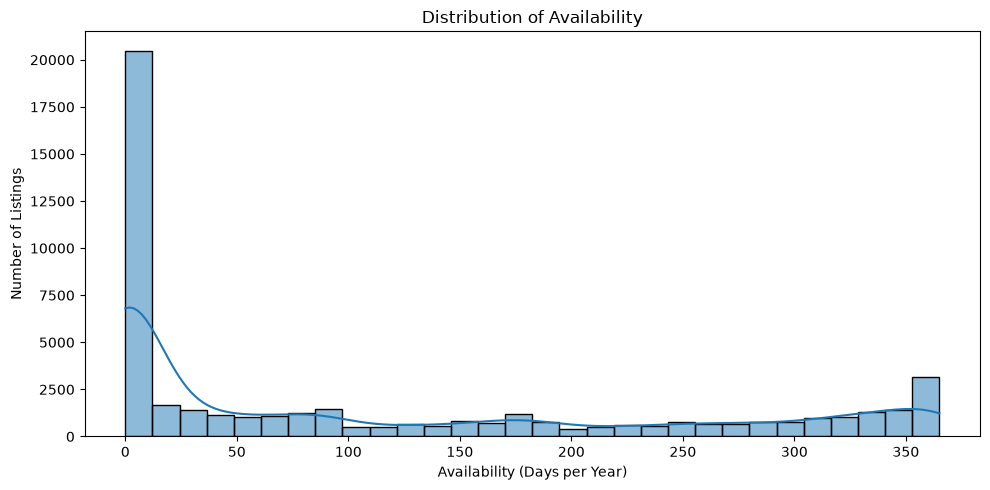

In [49]:
plt.figure(figsize=(10, 5))

sns.histplot(
    airbnb_df["availability_365"],
    bins=30,
    kde=True
)

plt.title("Distribution of Availability")
plt.xlabel("Availability (Days per Year)")
plt.ylabel("Number of Listings")
plt.tight_layout()

plt.savefig("plots/availability_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [50]:
top_neighbourhoods = airbnb_df["neighbourhood"].value_counts().head(10)
print(top_neighbourhoods)

neighbourhood
Williamsburg          3919
Bedford-Stuyvesant    3710
Harlem                2658
Bushwick              2462
Upper West Side       1971
Hell's Kitchen        1958
East Village          1853
Upper East Side       1798
Crown Heights         1564
Midtown               1545
Name: count, dtype: int64


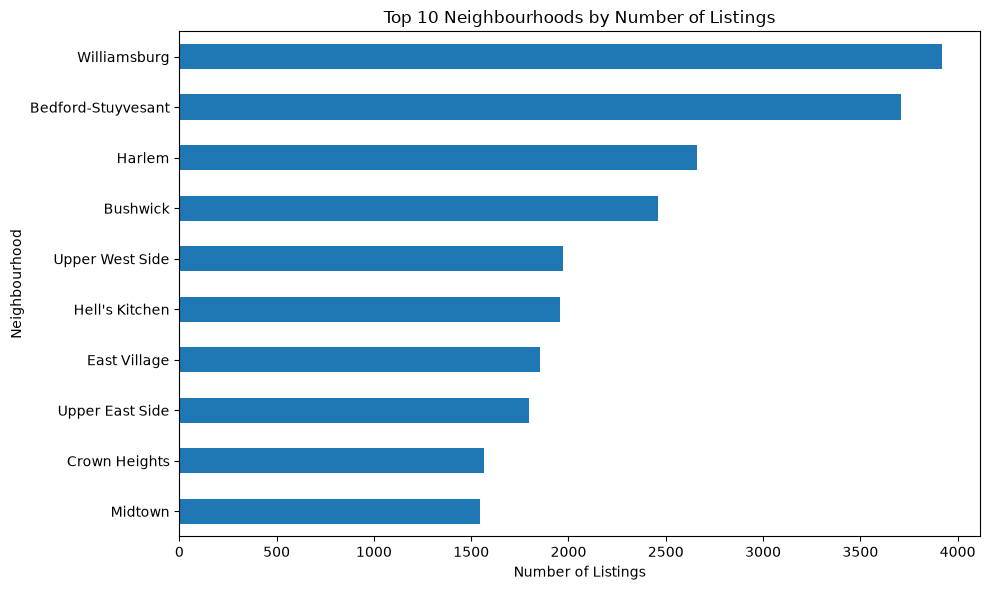

In [51]:
plt.figure(figsize=(10, 6))

top_neighbourhoods.sort_values().plot(kind="barh")

plt.title("Top 10 Neighbourhoods by Number of Listings")
plt.xlabel("Number of Listings")
plt.ylabel("Neighbourhood")
plt.tight_layout()

plt.savefig("plots/top_10_neighbourhoods.png", dpi=300, bbox_inches="tight")
plt.show()

In [52]:
X = airbnb_df.drop(columns=["price"])
y = airbnb_df["price"]
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (48884, 10)
Target shape: (48884,)


In [53]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (39107, 10)
Testing features: (9777, 10)
Training target: (39107,)
Testing target: (9777,)


In [54]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['latitude', 'longitude', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']

Categorical features:
['neighbourhood_group', 'neighbourhood', 'room_type']


In [55]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [56]:
X_train_processed = preprocessor.fit_transform(X_train)
print("Processed training data shape:", X_train_processed.shape)

Processed training data shape: (39107, 233)


In [57]:
X_test_processed = preprocessor.transform(X_test)
print("Processed test data shape:", X_test_processed.shape)

Processed test data shape: (9777, 233)


In [58]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()
linear_model.fit(X_train_processed, y_train)

y_pred_linear = linear_model.predict(X_test_processed)

print("Linear Regression prediction completed!")

Linear Regression prediction completed!


In [59]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred_linear)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_linear))
r2 = r2_score(y_test, y_pred_linear)

print("Linear Regression Results")
print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

Linear Regression Results
MAE: 60.58854381083452
RMSE: 111.1796785064628
R²: 0.28818057356927895


In [60]:
from sklearn.tree import DecisionTreeRegressor
tree_model = DecisionTreeRegressor(random_state=42)
tree_model.fit(X_train_processed, y_train)
print("Decision Tree Regression model trained successfully!")

Decision Tree Regression model trained successfully!


In [61]:
y_pred_tree = tree_model.predict(X_test_processed)

mae_tree = mean_absolute_error(y_test, y_pred_tree)
rmse_tree = np.sqrt(mean_squared_error(y_test, y_pred_tree))
r2_tree = r2_score(y_test, y_pred_tree)

print("Decision Tree Regression Performance")
print("MAE:", mae_tree)
print("RMSE:", rmse_tree)
print("R² Score:", r2_tree)

Decision Tree Regression Performance
MAE: 71.51396133783369
RMSE: 140.50723145312074
R² Score: -0.1368845422857301


In [62]:
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_processed, y_train)
print("Random Forest Regression model trained successfully!")

Random Forest Regression model trained successfully!


In [63]:
y_pred_rf = rf_model.predict(X_test_processed)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Regression Performance")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R² Score:", r2_rf)

Random Forest Regression Performance
MAE: 55.076436461666596
RMSE: 104.660598635428
R² Score: 0.36920907378634005


In [64]:
from sklearn.ensemble import GradientBoostingRegressor
gb_model = GradientBoostingRegressor(
    n_estimators=100,
    random_state=42
)
gb_model.fit(X_train_processed, y_train)
print("Gradient Boosting Regression model trained successfully!")

Gradient Boosting Regression model trained successfully!


In [65]:
y_pred_gb = gb_model.predict(X_test_processed)

mae_gb = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2_gb = r2_score(y_test, y_pred_gb)

print("Gradient Boosting Regression Performance")
print("MAE:", mae_gb)
print("RMSE:", rmse_gb)
print("R² Score:", r2_gb)

Gradient Boosting Regression Performance
MAE: 56.05875787507577
RMSE: 106.56718139882537
R² Score: 0.3460177411196127


In [66]:
from sklearn.ensemble import ExtraTreesRegressor
extra_model = ExtraTreesRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
extra_model.fit(X_train_processed, y_train)
print("Extra Trees Regression model trained successfully!")

Extra Trees Regression model trained successfully!


In [67]:
y_pred_rf_train = rf_model.predict(X_train_processed)
y_pred_rf_test = rf_model.predict(X_test_processed)

train_r2 = r2_score(y_train, y_pred_rf_train)
test_r2 = r2_score(y_test, y_pred_rf_test)

print("Random Forest Training R²:", train_r2)
print("Random Forest Testing R²:", test_r2)

Random Forest Training R²: 0.9170426132696846
Random Forest Testing R²: 0.36920907378634005


In [68]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [10, 20, 30, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

rf_random = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_grid,
    n_iter=15,
    cv=3,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1
)

rf_random.fit(X_train_processed, y_train)

print("Best parameters:")
print(rf_random.best_params_)

Best parameters:
{'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 30}


In [69]:
best_rf = rf_random.best_estimator_

y_pred_tuned = best_rf.predict(X_test_processed)

mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
r2_tuned = r2_score(y_test, y_pred_tuned)

print("Tuned Random Forest Performance")
print("MAE:", mae_tuned)
print("RMSE:", rmse_tuned)
print("R² Score:", r2_tuned)

Tuned Random Forest Performance
MAE: 53.31444096035998
RMSE: 102.63864142696285
R² Score: 0.3933463732560871


In [70]:
y_pred_tuned_train = best_rf.predict(X_train_processed)

train_r2_tuned = r2_score(y_train, y_pred_tuned_train)
test_r2_tuned = r2_score(y_test, y_pred_tuned)

print("Tuned Random Forest Training R²:", train_r2_tuned)
print("Tuned Random Forest Testing R²:", test_r2_tuned)

Tuned Random Forest Training R²: 0.7410873316607458
Tuned Random Forest Testing R²: 0.3933463732560871


In [71]:
print("Price Skewness:", airbnb_df["price"].skew())

Price Skewness: 3.3575984923095668


In [72]:
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

print("Original training target mean:", y_train.mean())
print("Log-transformed training target mean:", y_train_log.mean())

Original training target mean: 145.49538445802543
Log-transformed training target mean: 4.7348873417797215


In [73]:
rf_log_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=30,
    min_samples_split=5,
    min_samples_leaf=1,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

rf_log_model.fit(X_train_processed, y_train_log)

print("Log-target Random Forest trained successfully!")

Log-target Random Forest trained successfully!


In [74]:
# Predict log(price)
y_pred_log = rf_log_model.predict(X_test_processed)

# Convert predictions back to original price scale
y_pred_log_original = np.expm1(y_pred_log)

print("Predictions converted back to original price scale!")
print("First 5 predictions:", y_pred_log_original[:5])

Predictions converted back to original price scale!
First 5 predictions: [ 98.72918307  86.27565188 106.35958501  58.05096772  98.02422531]


In [75]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_log = mean_absolute_error(y_test, y_pred_log_original)
rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_log_original))
r2_log = r2_score(y_test, y_pred_log_original)

print("Log-target Random Forest Results:")
print("MAE:", mae_log)
print("RMSE:", rmse_log)
print("R²:", r2_log)

Log-target Random Forest Results:
MAE: 49.552415519889095
RMSE: 105.35551122195272
R²: 0.36080476895743496


In [76]:
feature_importance = pd.Series(
    best_rf.feature_importances_,
    index=preprocessor.get_feature_names_out()
).sort_values(ascending=False)

print("Top 15 Important Features:")
print(feature_importance.head(15))

Top 15 Important Features:
num__longitude                         0.154016
num__latitude                          0.125796
cat__room_type_Entire home/apt         0.117586
num__availability_365                  0.111034
cat__room_type_Private room            0.092291
num__minimum_nights                    0.065791
num__reviews_per_month                 0.058889
num__number_of_reviews                 0.052227
num__calculated_host_listings_count    0.051903
cat__neighbourhood_group_Manhattan     0.025241
cat__neighbourhood_Midtown             0.019423
cat__neighbourhood_Tribeca             0.009465
cat__neighbourhood_group_Brooklyn      0.008845
cat__neighbourhood_group_Queens        0.008536
cat__room_type_Shared room             0.007750
dtype: float64


In [77]:
model_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "Extra Trees",
        "Tuned Random Forest",
        "Log-target Random Forest"
    ],
    "MAE": [
        60.5885,
        71.5140,
        55.0764,
        56.0588,
        56.0975,
        53.3144,
        49.5524
    ],
    "RMSE": [
        111.1797,
        140.5072,
        104.6606,
        106.5672,
        108.1110,
        102.6386,
        105.3555
    ],
    "R2": [
        0.2882,
        -0.1369,
        0.3692,
        0.3460,
        0.3269,
        0.3933,
        0.3608
    ]
})

print(model_results.to_string(index=False))

                   Model     MAE     RMSE      R2
       Linear Regression 60.5885 111.1797  0.2882
           Decision Tree 71.5140 140.5072 -0.1369
           Random Forest 55.0764 104.6606  0.3692
       Gradient Boosting 56.0588 106.5672  0.3460
             Extra Trees 56.0975 108.1110  0.3269
     Tuned Random Forest 53.3144 102.6386  0.3933
Log-target Random Forest 49.5524 105.3555  0.3608


In [78]:
y_train_pred_final = best_rf.predict(X_train_processed)
y_test_pred_final = best_rf.predict(X_test_processed)

train_r2_final = r2_score(y_train, y_train_pred_final)
test_r2_final = r2_score(y_test, y_test_pred_final)

print("Training R²:", train_r2_final)
print("Testing R²:", test_r2_final)
print("R² Gap:", train_r2_final - test_r2_final)

Training R²: 0.7410873316607458
Testing R²: 0.3933463732560871
R² Gap: 0.3477409584046587


In [79]:
from sklearn.pipeline import Pipeline

final_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", best_rf)
])

print("Final pipeline created successfully!")

Final pipeline created successfully!


In [80]:
final_pipeline.fit(X_train, y_train)
print("Final pipeline trained successfully!")

Final pipeline trained successfully!


In [81]:
import joblib
joblib.dump(final_pipeline, "airbnb_price_model.pkl")
print("Model pipeline saved successfully!")

Model pipeline saved successfully!


In [82]:
loaded_model = joblib.load("airbnb_price_model.pkl")
print("Saved model loaded successfully!")
print(type(loaded_model))

Saved model loaded successfully!
<class 'sklearn.pipeline.Pipeline'>


In [83]:
sample_input = pd.DataFrame([{
    "neighbourhood_group": "Manhattan",
    "neighbourhood": "Midtown",
    "latitude": 40.7549,
    "longitude": -73.9840,
    "room_type": "Entire home/apt",
    "minimum_nights": 3,
    "number_of_reviews": 50,
    "reviews_per_month": 2.0,
    "calculated_host_listings_count": 2,
    "availability_365": 200
}])

sample_prediction = loaded_model.predict(sample_input)

print("Predicted Airbnb Price: $", round(sample_prediction[0], 2))

Predicted Airbnb Price: $ 254.26


In [84]:
location_lookup = (
    airbnb_df
    .groupby(["neighbourhood_group", "neighbourhood"])
    .agg(
        latitude=("latitude", "mean"),
        longitude=("longitude", "mean")
    )
    .reset_index()
)

location_lookup.to_csv("location_lookup.csv", index=False)

print("Location lookup created successfully!")
print("Number of neighbourhoods:", len(location_lookup))
print(location_lookup.head())

Location lookup created successfully!
Number of neighbourhoods: 221
  neighbourhood_group neighbourhood   latitude  longitude
0               Bronx      Allerton  40.865292 -73.858727
1               Bronx    Baychester  40.873616 -73.842967
2               Bronx       Belmont  40.855062 -73.887109
3               Bronx     Bronxdale  40.854731 -73.866287
4               Bronx   Castle Hill  40.816889 -73.847000
